In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import decimate, butter, filtfilt
import adi
import time
import gc

import asyncio
import nest_asyncio
from IPython.display import clear_output

from pynq import Overlay, allocate

nest_asyncio.apply()

# ============================================================
# 0. Pluto / Python 원본 파라미터
# ============================================================

fc = int(5.1e9)

fs_pluto = int(1e6)
fs_proc = int(100e3)
decim = 10

capture_time = 1.0      # 처음은 1초만. 이후 3초, 5초로 늘리기

rx_buffer_size = 65536

tx_amp = 8192
tx_rf_gain = 0
rx_gain = 30

hp_cutoff = 2

# ============================================================
# 1. FPGA STFT 파라미터
# ============================================================

WIN_SIZE = 256
NUM_FRAMES = 256
HOP = 26
FFT_SIZE = 1024

INPUT_SIZE = WIN_SIZE + (NUM_FRAMES - 1) * HOP
OUTPUT_SIZE = NUM_FRAMES * FFT_SIZE

# ============================================================
# 2. Plot 설정
# ============================================================

freq_limit = 3000
plot_ylim = 2000

db_min = -45
db_max = 0

# 처음 FPGA 결과는 값 범위를 모를 수 있으므로 ref는 이후 조정 가능
fixed_ref = 2500
cmap_name = "viridis"

# ============================================================
# 3. Q8.8 설정
# ============================================================

Q_FRAC = 8
Q_SCALE = 2 ** Q_FRAC
Q_INT_MIN = -32768
Q_INT_MAX = 32767

q88_gain = 1.0

print("Parameters loaded")
print("INPUT_SIZE :", INPUT_SIZE)
print("OUTPUT_SIZE:", OUTPUT_SIZE)
print("fs_pluto   :", fs_pluto)
print("fs_proc    :", fs_proc)
print("decim      :", decim)

Parameters loaded
INPUT_SIZE : 6886
OUTPUT_SIZE: 262144
fs_pluto   : 1000000
fs_proc    : 100000
decim      : 10


In [2]:
# ============================================================
# Overlay load
# ============================================================

BITSTREAM = "stft.bit"   # 실제 bitstream 파일명으로 수정

ol = Overlay(BITSTREAM)
ol.download()

print("Overlay loaded:", BITSTREAM)
print("\nAvailable IPs:")
for name in ol.ip_dict.keys():
    print(" -", name, ":", ol.ip_dict[name].get("type", ""))

# ============================================================
# DMA select
# ============================================================

dma_name = None

for name, info in ol.ip_dict.items():
    ip_type = info.get("type", "").lower()
    if "axi_dma" in ip_type or "dma" in name.lower():
        dma_name = name
        break

if dma_name is None:
    raise RuntimeError("DMA IP를 못 찾음. 위 IP 목록에서 axi_dma 이름 확인 필요.")

dma = getattr(ol, dma_name)
print("\nDMA selected:", dma_name)

# ============================================================
# HLS IP start
# 문서 기준: stft_buffer / windowing / fft 계열 IP를 auto_restart로 시작
# ============================================================

start_keywords = ["stft", "buffer", "window", "fft"]
started_ips = []

for name in ol.ip_dict.keys():
    if name == dma_name:
        continue

    lname = name.lower()
    if any(k in lname for k in start_keywords):
        try:
            ip = getattr(ol, name)
            ip.write(0x00, 0x81)   # ap_start=1, auto_restart=1
            started_ips.append(name)
            print("Started IP:", name)
        except Exception as e:
            print("Start skipped:", name, repr(e))

print("Started IPs:", started_ips)

# ============================================================
# DMA buffers
# ============================================================

input_buffer = allocate(shape=(INPUT_SIZE,), dtype=np.uint32)
output_buffer = allocate(shape=(OUTPUT_SIZE,), dtype=np.uint32)

print("input_buffer :", input_buffer.shape, input_buffer.dtype)
print("output_buffer:", output_buffer.shape, output_buffer.dtype)

Overlay loaded: stft.bit

Available IPs:
 - fft_0 : xilinx.com:hls:fft:1.0
 - stft_buffer_0 : xilinx.com:hls:stft_buffer:1.0
 - windowing_0 : xilinx.com:hls:windowing:1.0
 - axi_dma_0 : xilinx.com:ip:axi_dma:7.1
 - processing_system7_0 : xilinx.com:ip:processing_system7:5.5

DMA selected: axi_dma_0
Started IP: fft_0
Started IP: stft_buffer_0
Started IP: windowing_0
Started IPs: ['fft_0', 'stft_buffer_0', 'windowing_0']
input_buffer : (6886,) uint32
output_buffer: (262144,) uint32


In [3]:
# ============================================================
# Pluto USB setup
# ============================================================

sdr = adi.Pluto("usb:")

try:
    sdr.tx_destroy_buffer()
except Exception:
    pass

try:
    sdr.rx_destroy_buffer()
except Exception:
    pass

sdr.sample_rate = fs_pluto

sdr.rx_lo = fc
sdr.tx_lo = fc

sdr.rx_rf_bandwidth = int(800e3)
sdr.tx_rf_bandwidth = int(800e3)

sdr.rx_buffer_size = rx_buffer_size

sdr.gain_control_mode_chan0 = "manual"
sdr.rx_hardwaregain_chan0 = rx_gain
sdr.tx_hardwaregain_chan0 = tx_rf_gain

# Baseband DC CW TX
N_tx = 16384
tx_sig = np.ones(N_tx, dtype=np.complex64) * tx_amp

sdr.tx_cyclic_buffer = True
sdr.tx(tx_sig)

print("========================================")
print("Pluto ready")
print("========================================")
print(f"RF center frequency    : {fc/1e9:.3f} GHz")
print(f"Pluto sample rate      : {fs_pluto/1e6:.3f} MHz")
print(f"Processing sample rate : {fs_proc/1e3:.1f} kHz")
print(f"RX buffer size         : {sdr.rx_buffer_size}")
print(f"TX amp                 : {tx_amp}")
print(f"TX RF gain             : {sdr.tx_hardwaregain_chan0}")
print(f"RX gain                : {sdr.rx_hardwaregain_chan0}")
print("TX started: Baseband DC CW")

Pluto ready
RF center frequency    : 5.100 GHz
Pluto sample rate      : 1.000 MHz
Processing sample rate : 100.0 kHz
RX buffer size         : 65536
TX amp                 : 8192
TX RF gain             : 0
RX gain                : 30
TX started: Baseband DC CW


In [4]:
# ============================================================
# Q8.8 packing / unpacking
# ============================================================

def complex_to_q88_u32(x_complex, gain=1.0):
    x_scaled = x_complex * gain

    i_i16 = np.round(np.real(x_scaled) * Q_SCALE)
    q_i16 = np.round(np.imag(x_scaled) * Q_SCALE)

    i_i16 = np.clip(i_i16, Q_INT_MIN, Q_INT_MAX).astype(np.int16)
    q_i16 = np.clip(q_i16, Q_INT_MIN, Q_INT_MAX).astype(np.int16)

    i_u16 = i_i16.astype(np.uint16)
    q_u16 = q_i16.astype(np.uint16)

    packed = (i_u16.astype(np.uint32) << 16) | q_u16.astype(np.uint32)

    return packed.astype(np.uint32), i_i16, q_i16


def unpack_u32_to_iq(packed):
    packed = packed.astype(np.uint32)

    i_u16 = ((packed >> 16) & 0xFFFF).astype(np.uint16)
    q_u16 = (packed & 0xFFFF).astype(np.uint16)

    i_i16 = i_u16.view(np.int16)
    q_i16 = q_u16.view(np.int16)

    return i_i16, q_i16


# ============================================================
# Preprocess: Pluto raw IQ -> rx_hp at 100 kHz
# ============================================================

def preprocess_iq(rx):
    rx = rx.astype(np.complex64)

    # DC removal
    rx_dc = rx - np.mean(rx)

    # 1 MHz -> 100 kHz
    rx_100k = decimate(
        rx_dc,
        decim,
        ftype="fir",
        zero_phase=True
    )

    # High-pass clutter removal
    b, a = butter(
        3,
        hp_cutoff / (fs_proc / 2),
        btype="highpass"
    )

    rx_hp_real = filtfilt(b, a, np.real(rx_100k))
    rx_hp_imag = filtfilt(b, a, np.imag(rx_100k))
    rx_hp = rx_hp_real + 1j * rx_hp_imag

    return rx_hp.astype(np.complex64)


# ============================================================
# Blocker: stream samples -> 6886 sample blocks
# ============================================================

class BlockMaker:
    def __init__(self, block_size):
        self.block_size = block_size
        self.buf = np.array([], dtype=np.complex64)

    def push(self, x):
        self.buf = np.concatenate([self.buf, x.astype(np.complex64)])

        blocks = []

        while len(self.buf) >= self.block_size:
            block = self.buf[:self.block_size].copy()
            blocks.append(block)

            # 실시간성 우선: non-overlap block
            # 필요하면 여기서 block 간 overlap 정책 추가 가능
            self.buf = self.buf[self.block_size:]

        return blocks


# ============================================================
# FPGA STFT function
# ============================================================

def run_fpga_stft_packed(packed_block):
    assert packed_block.shape == (INPUT_SIZE,)
    assert packed_block.dtype == np.uint32

    np.copyto(input_buffer, packed_block)
    output_buffer[:] = 0

    dma.recvchannel.transfer(output_buffer)
    dma.sendchannel.transfer(input_buffer)

    dma.sendchannel.wait()
    dma.recvchannel.wait()

    real_i16, imag_i16 = unpack_u32_to_iq(output_buffer)

    stft_complex = real_i16.astype(np.float32) + 1j * imag_i16.astype(np.float32)
    stft_complex = stft_complex.reshape(NUM_FRAMES, FFT_SIZE)

    return stft_complex


# ============================================================
# Plot
# ============================================================

def plot_stft_complex(stft_complex, title="Task 3: FPGA STFT Plot"):
    assert stft_complex.shape == (NUM_FRAMES, FFT_SIZE)

    mag = np.abs(stft_complex)

    # 원본 Python 코드처럼 fixed_ref 기준으로 고정
    ref = fixed_ref

    S_db = 20 * np.log10((mag + 1e-12) / (ref + 1e-12))
    S_db = np.clip(S_db, db_min, db_max)

    f = np.fft.fftshift(np.fft.fftfreq(FFT_SIZE, d=1/fs_proc))
    S_db_shift = np.fft.fftshift(S_db, axes=1)

    freq_mask = (f >= -freq_limit) & (f <= freq_limit)

    S_plot = S_db_shift[:, freq_mask].T
    f_plot = f[freq_mask]
    t_plot = np.arange(NUM_FRAMES) * HOP / fs_proc

    clear_output(wait=True)

    print("========================================")
    print(title)
    print("========================================")
    print("mag max    :", np.max(mag))
    print("mag 99.8%  :", np.percentile(mag, 99.8))
    print("mag median :", np.median(mag))
    print("ref        :", ref)

    plt.figure(figsize=(12, 6))
    plt.imshow(
        S_plot,
        aspect="auto",
        origin="lower",
        extent=[t_plot[0], t_plot[-1], f_plot[0], f_plot[-1]],
        vmin=db_min,
        vmax=db_max,
        cmap=cmap_name
    )
    plt.colorbar(label="Magnitude [dB]")
    plt.xlabel("Time [s]")
    plt.ylabel("Doppler Frequency [Hz]")
    plt.title(title)
    plt.ylim(-plot_ylim, plot_ylim)
    plt.axhline(0, color="white", linestyle="--", linewidth=1)
    plt.tight_layout()
    plt.show()

    return S_plot


print("Utility functions loaded")

Utility functions loaded


In [5]:
async def task1_pluto_reader(raw_queue, total_blocks):
    """
    [Task 1] Pluto 송수신 및 데이터 전처리
    - Pluto RX
    - DC removal
    - decimation 1 MHz -> 100 kHz
    - high-pass clutter removal
    - 6886 sample block 생성
    - Q8.8 변환
    - uint32 packing
    - raw_queue에 packed_block 전달
    """
    print("Task 1: Pluto reader/preprocessor started")

    block_maker = BlockMaker(INPUT_SIZE)
    produced_blocks = 0

    while produced_blocks < total_blocks:
        # Pluto에서 한 block 수신
        rx_raw = np.array(sdr.rx()).astype(np.complex64)

        # 전처리
        rx_hp = preprocess_iq(rx_raw)

        # 6886 block 생성
        blocks = block_maker.push(rx_hp)

        for x_block in blocks:
            # Q8.8 + packing
            packed_block, i_i16, q_i16 = complex_to_q88_u32(
                x_block,
                gain=q88_gain
            )

            # 상태 출력
            if produced_blocks == 0:
                print("Task 1 first block check")
                print("x_block shape:", x_block.shape)
                print("packed_block shape:", packed_block.shape)
                print("packed_block dtype:", packed_block.dtype)
                print("I zero ratio [%]:", np.mean(i_i16 == 0) * 100)
                print("Q zero ratio [%]:", np.mean(q_i16 == 0) * 100)
                print("I clipping ratio [%]:", np.mean((i_i16 == Q_INT_MIN) | (i_i16 == Q_INT_MAX)) * 100)
                print("Q clipping ratio [%]:", np.mean((q_i16 == Q_INT_MIN) | (q_i16 == Q_INT_MAX)) * 100)

            await raw_queue.put(packed_block.copy())

            produced_blocks += 1

            if produced_blocks >= total_blocks:
                break

        await asyncio.sleep(0)

    await raw_queue.put(None)
    print("Task 1: Pluto reader/preprocessor finished")

In [6]:
async def task2_fpga_stft(raw_queue, plot_queue):
    """
    [Task 2] FPGA STFT 처리
    - raw_queue에서 packed_block 수신
    - DMA send/recv
    - output unpack
    - reshape (256, 1024)
    - plot_queue에 최신 stft_complex 전달
    """
    print("Task 2: FPGA STFT worker started")

    processed_blocks = 0

    while True:
        packed_block = await raw_queue.get()

        if packed_block is None:
            # Task 3 종료 신호 전달
            await plot_queue.put(None)
            raw_queue.task_done()
            break

        t0 = time.time()
        stft_complex = run_fpga_stft_packed(packed_block)
        t1 = time.time()

        if processed_blocks == 0:
            print("Task 2 first FPGA result check")
            print("stft_complex shape:", stft_complex.shape)
            print("stft mag max:", np.max(np.abs(stft_complex)))
            print("stft mag median:", np.median(np.abs(stft_complex)))
            print("FPGA elapsed:", t1 - t0, "s")

        # plot_queue는 화면 표시용이므로 최신 STFT 결과만 유지
        # 오래된 plot 대기 결과는 버림
        while not plot_queue.empty():
            try:
                _ = plot_queue.get_nowait()
                plot_queue.task_done()
            except Exception:
                break

        await plot_queue.put(stft_complex.copy())

        processed_blocks += 1
        raw_queue.task_done()

        await asyncio.sleep(0)

    print("Task 2: FPGA STFT worker finished")

In [7]:
async def task3_plot(plot_queue, history_blocks=75, refresh_period=0.5):
    """
    [Task 3] Real-time rolling Doppler map

    역할:
    - Task 2에서 넘어온 stft_complex를 모두 받음
    - STFT block을 시간축 방향으로 계속 append
    - figure/colorbar는 처음 한 번만 생성
    - 이후에는 imshow의 data만 갱신
    - 화면 draw는 refresh_period마다만 수행
    - 데이터는 버리지 않음
      단, history_blocks보다 오래된 화면 구간은 rolling window 밖으로 밀림
    """

    print("Task 3: Real-time rolling plot worker started")

    # ============================================================
    # 1. 주파수축 준비
    # ============================================================

    f = np.fft.fftshift(np.fft.fftfreq(FFT_SIZE, d=1 / fs_proc))
    freq_mask = (f >= -freq_limit) & (f <= freq_limit)
    f_plot = f[freq_mask]
    n_freq = np.sum(freq_mask)

    # ============================================================
    # 2. 시간축 rolling buffer 준비
    # ============================================================

    frames_per_block = NUM_FRAMES

    # 화면에 유지할 총 frame 수
    total_frames = history_blocks * frames_per_block

    # 화면에 표시되는 시간 길이
    history_time = total_frames * HOP / fs_proc

    # 초기 도플러맵 buffer
    # shape = 주파수 bin 수 x 시간 frame 수
    map_buffer = np.ones((n_freq, total_frames), dtype=np.float32) * db_min

    # ============================================================
    # 3. Figure는 처음 한 번만 생성
    # ============================================================

    fig, ax = plt.subplots(figsize=(14, 6))

    im = ax.imshow(
        map_buffer,
        aspect="auto",
        origin="lower",
        extent=[-history_time, 0, f_plot[0], f_plot[-1]],
        vmin=db_min,
        vmax=db_max,
        cmap=cmap_name
    )

    fig.colorbar(im, ax=ax, label="Magnitude [dB]")
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Doppler Frequency [Hz]")
    ax.set_title("Real-time FPGA STFT Micro-Doppler Map")
    ax.set_ylim(-plot_ylim, plot_ylim)
    ax.axhline(0, color="white", linestyle="--", linewidth=1)
    fig.tight_layout()

    # Jupyter에서 같은 출력 위치를 계속 갱신하기 위한 handle
    display_handle = display(fig, display_id=True)

    # ============================================================
    # 4. Plot loop
    # ============================================================

    received_blocks = 0
    update_count = 0
    last_draw_time = time.time()

    while True:
        # Task 2가 넘긴 STFT 결과를 하나씩 받음
        stft_complex = await plot_queue.get()

        # 종료 신호
        if stft_complex is None:
            plot_queue.task_done()

            # 종료 직전 마지막 상태 한 번 더 표시
            im.set_data(map_buffer)
            ax.set_title(
                f"Final Real-time FPGA STFT Micro-Doppler Map "
                f"| received {received_blocks} blocks"
            )
            display_handle.update(fig)

            print("Task 3: Real-time rolling plot worker finished")
            print("Task 3 received blocks:", received_blocks)
            print("Task 3 display updates:", update_count)
            print("Final map_buffer shape:", map_buffer.shape)
            print("History time [s]:", history_time)
            return

        # ========================================================
        # 5. STFT complex -> dB map block
        # ========================================================

        # stft_complex shape = (NUM_FRAMES, FFT_SIZE)
        mag = np.abs(stft_complex)

        # Python 원본 plot 기준 사용
        ref = fixed_ref

        S_db = 20 * np.log10((mag + 1e-12) / (ref + 1e-12))
        S_db = np.clip(S_db, db_min, db_max)

        # FFT축 정렬
        S_db_shift = np.fft.fftshift(S_db, axes=1)

        # 필요한 도플러 주파수 범위만 선택
        # S_block shape = freq x time
        S_block = S_db_shift[:, freq_mask].T.astype(np.float32)

        # ========================================================
        # 6. rolling append
        # ========================================================

        # 왼쪽으로 밀고, 오른쪽 끝에 최신 block 붙임
        map_buffer[:, :-frames_per_block] = map_buffer[:, frames_per_block:]
        map_buffer[:, -frames_per_block:] = S_block

        received_blocks += 1
        plot_queue.task_done()

        # ========================================================
        # 7. 화면 갱신은 refresh_period마다만 수행
        # ========================================================

        now = time.time()

        if (now - last_draw_time) >= refresh_period:
            im.set_data(map_buffer)
            ax.set_title(
                f"Real-time FPGA STFT Micro-Doppler Map "
                f"| block {received_blocks}, update {update_count}"
            )

            display_handle.update(fig)

            update_count += 1
            last_draw_time = now

            print(
                "Task 3 update:",
                update_count,
                "| received blocks:",
                received_blocks,
                "| plot_queue size:",
                plot_queue.qsize()
            )

        await asyncio.sleep(0)

Pipeline configuration
TOTAL_BLOCKS     : 75
HISTORY_BLOCKS   : 75
REFRESH_PERIOD   : 0.5 s
raw_queue max    : 3
plot_queue max   : 8
Estimated duration [s]: 4.992
3초 뒤 측정 시작합니다. 움직일 준비하세요.
측정 시작
Task 1: Pluto reader/preprocessor started
Task 2: FPGA STFT worker started
Task 3: Real-time rolling plot worker started


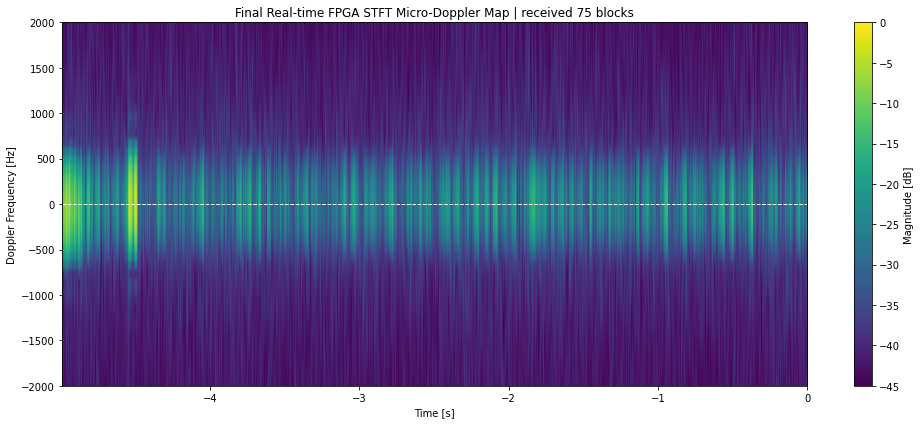

Task 1 first block check
x_block shape: (6886,)
packed_block shape: (6886,)
packed_block dtype: uint32
I zero ratio [%]: 0.08713331397037467
Q zero ratio [%]: 0.02904443799012489
I clipping ratio [%]: 0.0
Q clipping ratio [%]: 0.0
Task 2 first FPGA result check
stft_complex shape: (256, 1024)
stft mag max: 1459.8308
stft mag median: 7.2111025
FPGA elapsed: 0.21094965934753418 s
Task 3 update: 1 | received blocks: 1 | plot_queue size: 0
Task 3 update: 2 | received blocks: 2 | plot_queue size: 0
Task 3 update: 3 | received blocks: 3 | plot_queue size: 0
Task 3 update: 4 | received blocks: 4 | plot_queue size: 0
Task 3 update: 5 | received blocks: 5 | plot_queue size: 0
Task 3 update: 6 | received blocks: 6 | plot_queue size: 0
Task 3 update: 7 | received blocks: 7 | plot_queue size: 0
Task 3 update: 8 | received blocks: 8 | plot_queue size: 0
Task 3 update: 9 | received blocks: 9 | plot_queue size: 0
Task 3 update: 10 | received blocks: 10 | plot_queue size: 0
Task 3 update: 11 | receive

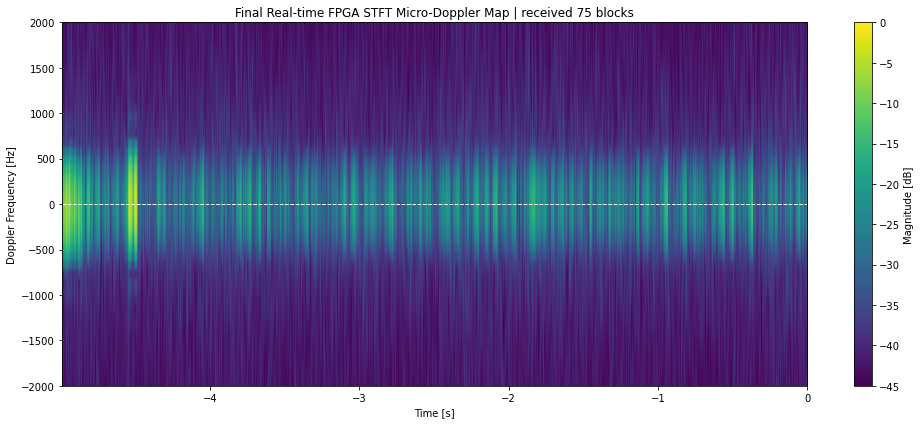

In [8]:
async def main_pipeline():
    """
    Pipeline 구조:

    Task 1:
        Pluto reader/preprocessor
        Pluto RX -> DC removal -> decimation -> HPF
        -> 6886 sample block
        -> Q8.8 packing
        -> raw_queue

    Task 2:
        FPGA STFT processor
        raw_queue -> DMA -> FPGA STFT
        -> stft_complex shape (256, 1024)
        -> plot_queue

    Task 3:
        Real-time rolling plot
        plot_queue -> magnitude/dB
        -> rolling map_buffer append
        -> imshow data update
    """

    # Task 1 -> Task 2
    raw_queue = asyncio.Queue(maxsize=3)

    # Task 2 -> Task 3
    # 병목을 확인하기 위해 일단 버리지 않고 queue에 쌓이게 둔다.
    # plot_queue가 계속 꽉 차면 Task 3 plot 병목임.
    plot_queue = asyncio.Queue(maxsize=8)

    # 1 block의 시간 길이:
    # NUM_FRAMES * HOP / fs_proc = 256 * 26 / 100000 = 0.06656 s
    # 75 blocks ≈ 4.99 s
    TOTAL_BLOCKS = 75

    # 화면에 표시할 rolling history 길이
    # 75 blocks면 약 5초 전체가 화면에 유지됨.
    HISTORY_BLOCKS = 75

    # 화면 갱신 주기
    # 0.5초 = 약 2 fps
    REFRESH_PERIOD = 0.5

    print("========================================")
    print("Pipeline configuration")
    print("========================================")
    print("TOTAL_BLOCKS     :", TOTAL_BLOCKS)
    print("HISTORY_BLOCKS   :", HISTORY_BLOCKS)
    print("REFRESH_PERIOD   :", REFRESH_PERIOD, "s")
    print("raw_queue max    :", raw_queue.maxsize)
    print("plot_queue max   :", plot_queue.maxsize)
    print("Estimated duration [s]:", TOTAL_BLOCKS * NUM_FRAMES * HOP / fs_proc)
    print("========================================")

    print("3초 뒤 측정 시작합니다. 움직일 준비하세요.")
    await asyncio.sleep(3)
    print("측정 시작")

    task1 = asyncio.create_task(
        task1_pluto_reader(raw_queue, TOTAL_BLOCKS)
    )

    task2 = asyncio.create_task(
        task2_fpga_stft(raw_queue, plot_queue)
    )

    task3 = asyncio.create_task(
        task3_plot(
            plot_queue,
            history_blocks=HISTORY_BLOCKS,
            refresh_period=REFRESH_PERIOD
        )
    )

    await asyncio.gather(task1, task2, task3)

    print("All tasks completed")


try:
    await main_pipeline()
except Exception as e:
    print("Pipeline error:", repr(e))

In [ ]:
# ============================================================
# Safe cleanup
# ============================================================

try:
    sdr.tx_destroy_buffer()
    print("TX buffer destroyed")
except Exception as e:
    print("TX cleanup skipped:", repr(e))

try:
    sdr.rx_destroy_buffer()
    print("RX buffer destroyed")
except Exception as e:
    print("RX cleanup skipped:", repr(e))

try:
    input_buffer.freebuffer()
    print("input_buffer freed")
except Exception as e:
    print("input_buffer free skipped:", repr(e))

try:
    output_buffer.freebuffer()
    print("output_buffer freed")
except Exception as e:
    print("output_buffer free skipped:", repr(e))

import gc
gc.collect()

print("Cleanup done")